# ChimpUFE fine-tuning &mdash; data construction and face-crop mining pipeline

This notebook is the **canonical data documentation** of the ChimpUFE
fine-tuning experiment on a 20-chimpanzee identity dataset (thesis
section §`sec:chimpufe_finetune`). It mirrors *exactly* the dataset that
`chimpUFE_finetune_intensive.py` consumes in production (see
`run_ceci/run_finetune_t3_frontal55.slurm`) and is intended to be the
sole supporting artefact for writing Chapter `ch:data`.

The fine-tuning script consumes a **three-tier** dataset, each with its
own quality, augmentation policy, per-sample loss weight $\lambda_t$ and
per-tier sample multiplier $m_t$:

| Tier | Source folder (under `ChimpPic/face_recognition_db/`) | Quality | Loss weight $\lambda_t$ | Sample mult. $m_t$ | Augmentation |
|------|--------------------------------------------------------|---------|--------------------------|---------------------|--------------|
| 1    | `face_crops_chimpRec_cropped/{train,val}/<chimp>/`     | High    | 1.000                    | 5                   | Heavy        |
| 2    | `student_face_crops/<Name - XX>/`                      | Medium  | 1.500                    | 3                   | Moderate     |
| 3    | `face_crops_frontal_55/<chimp>/`                       | Low / noisy | 0.045                | 1                   | None (resize + normalise only) |

A separate flat folder `face_recognition_db/test/` is **never seen during
training** and is reserved for the held-out test set whose evaluation is
reported in the matching evaluation notebook
(`chimpUFE_test_evaluation.ipynb`).

This notebook produces:

1. **A precise accounting of the data corpus** &mdash; counts per chimp,
   per tier and per split, recomputed live from disk so the numbers can
   never drift from the trainer's view.
2. **An explicit description of the train/val/test splits** for each
   tier, with the per-tier rationale.
3. **A reproducible visualisation of the sampling and loss-weighting
   strategy**, including the effective per-tier gradient share that the
   trainer actually sees ($\rho_t \approx 49.7 / 34.8 / 15.5\%$).
4. **A consistent colour palette** &mdash; every plot in the notebook
   uses the same colour for a given tier (`TIER_COLORS`), so the figures
   compose visually inside the manuscript.

All figures are exported as PDF + PNG into a local `figures/` directory
and all summary tables as CSV into `tables/`, ready to be inserted into
the LaTeX manuscript with `\input{...}` or `\includegraphics{...}`.



## 1.&nbsp; Setup, imports and plot style configuration

We adopt a **paper-grade** Matplotlib configuration: a serif font matching the
LaTeX body text, slightly enlarged tick and axis labels, a colour-blind-safe
qualitative palette (`colorblind` / `Set2`), and a tight default layout. All
figures are saved both as **vector PDF** (for crisp inclusion in the
manuscript) and as a 300&nbsp;DPI PNG (for HTML or quick previews). The helper
`save_fig(name)` enforces this consistently across the notebook.


In [90]:
from __future__ import annotations

import json
import math
import random
import re
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# ---------------------------------------------------------------------------
# Publication-grade plot style.
# ---------------------------------------------------------------------------
sns.set_theme(context="paper", style="whitegrid")
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Times"],
    "mathtext.fontset": "dejavuserif",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------------------------------------------------------
# CANONICAL COLOUR PALETTE.
# Every figure in this notebook uses these colours so that "Tier 1" always
# looks the same in the thesis. Train uses the saturated colour, val uses
# the same hue at lower saturation (helper `_lighter` below).
# ---------------------------------------------------------------------------
TIER_COLORS = {
    "Tier 1": "#1f77b4",   # curated      -> blue
    "Tier 2": "#ff7f0e",   # student      -> orange
    "Tier 3": "#2ca02c",   # video crops  -> green
    "Test":   "#7f7f7f",   # held out     -> grey
}
CHIMP_CMAP = plt.get_cmap("tab20")  # consistent per-chimp colouring


def _lighter(hex_color: str, alpha: float = 0.55) -> tuple:
    """Return a lighter (alpha-blended on white) version of ``hex_color``."""
    rgb = mpl.colors.to_rgb(hex_color)
    return tuple(1.0 - alpha * (1.0 - c) for c in rgb)


TIER_COLORS_VAL = {k: _lighter(v) for k, v in TIER_COLORS.items()}

NOTEBOOK_DIR = Path.cwd()
FIG_DIR = NOTEBOOK_DIR / "results" / "figures"
TAB_DIR = NOTEBOOK_DIR / "results" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(name: str, fig=None) -> None:
    """Save the current (or given) figure as both PDF and PNG into FIG_DIR."""
    fig = fig or plt.gcf()
    pdf_path = FIG_DIR / f"{name}.pdf"
    png_path = FIG_DIR / f"{name}.png"
    fig.savefig(pdf_path)
    fig.savefig(png_path)
    print(f"[fig] {pdf_path.relative_to(NOTEBOOK_DIR)}")


print("Figures dir :", FIG_DIR)
print("Tables  dir :", TAB_DIR)
print("Tier palette:", TIER_COLORS)


Figures dir : /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/data_engine/results/figures
Tables  dir : /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/data_engine/results/tables
Tier palette: {'Tier 1': '#1f77b4', 'Tier 2': '#ff7f0e', 'Tier 3': '#2ca02c', 'Test': '#7f7f7f'}


## 2.&nbsp; Canonical chimpanzee identities and name aliases

The 20 chimpanzees that appear in the corpus are referenced under several
spelling variants across the different annotation sources. The student
folders use a mix of capitalised forms and two-letter initial codes
(`Amadi - AD`, `Kassongo -KG`), the named tracking files inherited from the
HOTA pipeline (§`sec:hota_data`) use the original Lingala spellings
(`talissa`, `mazingara`), while the curated `train/` and `val/` folders use
the simplified forms preferred by our collaborators (`talisa`,
`mazingira`). Without explicit normalisation, the same individual would be
scattered across two or three classes in the dataset, silently inflating the
class count and corrupting per-class metrics.

We define a single canonical name per individual together with two lookup
tables:

* `NAME_ALIASES` maps known orthographic variants to their canonical name;
* `INITIAL_TO_NAME` maps the two-letter codes used in the test filenames
  (e.g. `AD1.png`) and student folders to their canonical name.

The function `canonical_name(raw)` resolves any folder or token to a
canonical identity, returning `None` if the token does not match any known
chimpanzee. This function is used everywhere downstream, ensuring that the
same individual is always counted under the same label.


In [91]:
CANONICAL_NAMES = [
    "amadi", "banalia", "binasera", "djiku", "ivan",
    "jeje", "kalemi", "kassongo", "kira", "lwama",
    "malago", "maniema", "mazingira", "muke", "nganja",
    "nzuri", "penda", "talisa", "tanganica", "tingitingi",
]

NAME_ALIASES = {
    "kalimi":    "kalemi",
    "talissa":   "talisa",
    "mazingara": "mazingira",
}

INITIAL_TO_NAME = {
    "AD": "amadi",   "BL": "banalia", "BS": "binasera", "DK": "djiku",
    "IV": "ivan",    "JJ": "jeje",    "KM": "kalemi",   "KG": "kassongo",
    "KR": "kira",    "LM": "lwama",   "MG": "malago",   "MM": "maniema",
    "MZ": "mazingira", "MK": "muke",  "NJ": "nganja",   "NR": "nzuri",
    "PD": "penda",   "TS": "talisa",  "TC": "tanganica", "TT": "tingitingi",
}

NAME_TO_INITIAL = {v: k for k, v in INITIAL_TO_NAME.items()}


def canonical_name(raw: str) -> str | None:
    """Resolve any folder or filename token to a canonical chimp name."""
    if raw is None:
        return None
    s = raw.strip().lower()
    if s in CANONICAL_NAMES:
        return s
    if s in NAME_ALIASES:
        return NAME_ALIASES[s]
    # 'Amadi - AD' style folder names: keep the leading word.
    first = s.split(" - ")[0].split("-")[0].strip()
    if first in CANONICAL_NAMES:
        return first
    if first in NAME_ALIASES:
        return NAME_ALIASES[first]
    # Trailing two-letter initial code: 'Kassongo -KG' -> 'KG'
    for tok in raw.replace("-", " ").split()[::-1]:
        tok_up = tok.strip().upper()
        if tok_up in INITIAL_TO_NAME:
            return INITIAL_TO_NAME[tok_up]
    return None


# Pretty summary table.
identity_rows = []
for name in CANONICAL_NAMES:
    aliases_for = [a for a, c in NAME_ALIASES.items() if c == name]
    identity_rows.append({
        "canonical_name":   name,
        "initial_code":     NAME_TO_INITIAL[name],
        "spelling_variants": ", ".join(aliases_for) if aliases_for else "&mdash;",
    })
identity_df = pd.DataFrame(identity_rows)
print(f"Number of canonical identities: {len(CANONICAL_NAMES)}")
identity_df


Number of canonical identities: 20


,canonical_name,initial_code,spelling_variants
0,amadi,AD,&mdash;
1,banalia,BL,&mdash;
2,binasera,BS,&mdash;
3,djiku,DK,&mdash;
4,ivan,IV,&mdash;
5,jeje,JJ,&mdash;
6,kalemi,KM,kalimi
7,kassongo,KG,&mdash;
8,kira,KR,&mdash;
9,lwama,LM,&mdash;


## 3.&nbsp; Repository layout and dataset roots

The face-recognition data is organised under
`ChimpPic/face_recognition_db/` of the project root. The folders that
this notebook scans &mdash; and that the trainer reads &mdash; are:

```text
ChimpPic/face_recognition_db/
├── face_crops_chimpRec_cropped/       # Tier 1 (production), YOLOX-recropped
│   ├── train/<chimp>/*.jpg            #   807 curated training crops
│   └── val/<chimp>/*.jpg              #   217 curated validation crops
├── face_crops_chimpRec/               # Tier 1 SOURCE before YOLOX face-recrop
│   ├── train/                         #   (kept on disk for traceability only)
│   └── val/
├── student_face_crops/                # Tier 2, student manual annotations
│   └── <Name - XX>/*                  #   ~522 images, per-chimp folders
├── face_crops_for_chimpufe/           # raw video reservoir (pre-filter)
├── face_crops_frontal_55/             # Tier 3 (production): frontal_score >= 0.55
│   └── <chimp>/*.jpg                  #   18,225 mined crops (47 - 3,691 / chimp)
├── test/                              # held-out test set, flat folder (AD1.png, ...)
└── evaluation/                        # single-image demo queries (notebook only)
```

**Why two Tier-1 folders?** `face_crops_chimpRec/{train,val}` is the
*manually curated* gallery exactly as it was assembled by our
collaborators. Those crops were extracted with a previous detector and
contained variable amounts of background. To make Tier&nbsp;1 visually
consistent with Tiers&nbsp;2 and&nbsp;3, we re-ran the YOLOX face
detector on each curated image with a permissive threshold
(`--conf 0.05 --min-px 0 --margin 0.0`) and saved the tightest
face-box crop into `face_crops_chimpRec_cropped/`. This is the folder
the trainer actually reads. The cell below resolves all paths and
asserts that every required directory exists.



In [92]:
def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "Code").exists() and (p / "ChimpPic").exists():
            return p
    return start


REPO_ROOT   = find_repo_root(NOTEBOOK_DIR)
DB_ROOT     = REPO_ROOT / "ChimpPic" / "face_recognition_db"

# --- Tier 1 (production: ChimpRec original) ---
TRAIN_ROOT       = DB_ROOT / "Tier1" / "chimpRecV1_faces" / "train"
VAL_ROOT         = DB_ROOT / "Tier1" / "chimpRecV1_faces" / "val"
# Original curated source (kept for traceability only; not consumed by the trainer)
TRAIN_ROOT_SRC   = DB_ROOT / "Tier1" / "chimpRecV1" / "train"
VAL_ROOT_SRC     = DB_ROOT / "Tier1" / "chimpRecV1" / "val"

# --- Tier 2 ---
STUDENT_ROOT     = DB_ROOT / "Tier2" / "student_face_crops"

# --- Tier 3 (production) ---
TIER3_ROOT       = DB_ROOT / "Tier3" / "face_crops_frontal_55"
# Raw reservoir consumed by filter_frontal_faces.py.
# On the CECI cluster the folder is named `face_crops_for_chimpufe`; locally
# it is `raw_face_crops_from_videos`. Pick whichever exists, falling back to
# the cluster name (used as the canonical name in the production command).
_RAW_CANDIDATES = [
    DB_ROOT / "Tier3" / "face_crops_for_chimpufe",
    DB_ROOT / "Tier3" / "raw_face_crops_from_videos",
]
RAW_MINED_ROOT = next((p for p in _RAW_CANDIDATES if p.exists()),
                     _RAW_CANDIDATES[0])

# --- Held out / demo ---
TEST_ROOT        = DB_ROOT / "Test" / "test_final"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def _exists_mark(p: Path) -> str:
    return "OK " if p.exists() else "MISS"


print(f"Repo root             : {REPO_ROOT}")
print(f"DB root               : {DB_ROOT}\n")
for label, p in [
    ("train (Tier 1, cropped) ", TRAIN_ROOT),
    ("val   (Tier 1, cropped) ", VAL_ROOT),
    ("train (Tier 1, source)  ", TRAIN_ROOT_SRC),
    ("val   (Tier 1, source)  ", VAL_ROOT_SRC),
    ("student (Tier 2)        ", STUDENT_ROOT),
    ("frontal_55 (Tier 3)     ", TIER3_ROOT),
    ("raw mined reservoir     ", RAW_MINED_ROOT),
    ("test (held out)         ", TEST_ROOT)
]:
    print(f"  [{_exists_mark(p)}] {label} -> {p}")


Repo root             : /home/users/t/r/trixen/ChimpRec
DB root               : /home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db

  [OK ] train (Tier 1, cropped)  -> /home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier1/chimpRecV1_faces/train
  [OK ] val   (Tier 1, cropped)  -> /home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier1/chimpRecV1_faces/val
  [OK ] train (Tier 1, source)   -> /home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier1/chimpRecV1/train
  [OK ] val   (Tier 1, source)   -> /home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier1/chimpRecV1/val
  [OK ] student (Tier 2)         -> /home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier2/student_face_crops
  [OK ] frontal_55 (Tier 3)      -> /home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier3/face_crops_frontal_55
  [OK ] raw mined reservoir      -> /home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier3/raw_face_crops_from_

In [93]:
def list_class_dirs(root: Path) -> list[Path]:
    """Return sub-directories of ``root`` whose name resolves to a canonical chimp."""
    if not root.exists():
        return []
    return sorted(p for p in root.iterdir() if p.is_dir() and canonical_name(p.name) is not None)


def count_images(folder: Path) -> int:
    if not folder.exists():
        return 0
    n = 0
    for p in folder.iterdir():
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            n += 1
        elif p.is_dir() and p.name == "images":
            n += sum(1 for q in p.iterdir() if q.is_file() and q.suffix.lower() in IMG_EXTS)
    return n


def per_chimp_counts(root: Path) -> pd.DataFrame:
    """Return a DataFrame with one row per canonical chimp and its image count."""
    counts: dict[str, int] = defaultdict(int)
    for d in list_class_dirs(root):
        c = canonical_name(d.name)
        counts[c] += count_images(d)
    rows = [{"chimp": name, "n_images": counts.get(name, 0)} for name in CANONICAL_NAMES]
    return pd.DataFrame(rows)


## 4.&nbsp; Tier&nbsp;1 &mdash; high-quality curated database

Tier&nbsp;1 is the **gold standard** of the corpus. It was hand-picked
from previous data-collection campaigns and visually verified by our
collaborators. Two on-disk variants of Tier&nbsp;1 exist:

* `face_crops_chimpRec/{train,val}` &mdash; the **original** curated
  collection. Crops were extracted with a previous detector and contain
  variable amounts of background.
* `face_crops_chimpRec_cropped/{train,val}` &mdash; the **production**
  Tier&nbsp;1, obtained by re-running our YOLOX face detector on each
  curated image with a permissive threshold (`--conf 0.05 --min-px 0
  --margin 0.0`) and saving the tightest face-box crop. This makes
  Tier&nbsp;1 visually consistent with Tiers&nbsp;2 and&nbsp;3 (the YOLOX
  retention rate is ${\sim}99\%$, with only 8 train images skipped over
  the entire 815-image source set).

The train/val split was set **once at curation time** and is never
re-shuffled, so the validation set is a strict, fixed held-out subset
that we use to monitor convergence and to early-stop.

During training, Tier&nbsp;1 receives the full augmentation pipeline
(random resized crop, rotation, perspective, colour jitter, gaussian
blur, random erase) because the original crops are sharp enough to
remain interpretable under aggressive transforms. They carry the largest
sample multiplier ($m_1 = 5$) and a unit loss weight
($\lambda_1 = 1.0$), so the network sees them roughly five times more
often than their raw frequency would suggest.

The cell below counts the production Tier&nbsp;1 (the cropped variant);
the original source folder is reported alongside for traceability.



In [94]:
tier1_train = per_chimp_counts(TRAIN_ROOT).rename(columns={"n_images": "train"})
tier1_val   = per_chimp_counts(VAL_ROOT).rename(columns={"n_images": "val"})
tier1 = tier1_train.merge(tier1_val, on="chimp")
tier1["total"] = tier1["train"] + tier1["val"]
tier1_sorted = tier1.sort_values("total", ascending=False).reset_index(drop=True)

# Source counts, for a YOLOX retention sanity-check (informational only).
src_train = per_chimp_counts(TRAIN_ROOT_SRC)["n_images"].sum() if TRAIN_ROOT_SRC.exists() else 0
src_val   = per_chimp_counts(VAL_ROOT_SRC)["n_images"].sum()   if VAL_ROOT_SRC.exists()   else 0

print(f"TIER 1 (production, YOLOX-recropped):")
print(f"  train images : {tier1['train'].sum()}")
print(f"  val   images : {tier1['val'].sum()}")
print(f"  total        : {tier1['total'].sum()}\n")
print(f"TIER 1 (original source, pre-recrop):")
print(f"  train images : {src_train}")
print(f"  val   images : {src_val}")
if (src_train + src_val) > 0:
    retained = tier1['total'].sum() / (src_train + src_val) * 100
    print(f"  YOLOX retention rate : {retained:.1f}%")
print()
tier1_sorted


TIER 1 (production, YOLOX-recropped):
  train images : 866
  val   images : 227
  total        : 1093

TIER 1 (original source, pre-recrop):
  train images : 867
  val   images : 227
  YOLOX retention rate : 99.9%



,chimp,train,val,total
0,amadi,56,14,70
1,banalia,54,14,68
2,ivan,51,13,64
3,djiku,49,13,62
4,lwama,49,13,62
5,penda,48,12,60
6,nzuri,44,12,56
7,maniema,44,12,56
8,binasera,44,11,55
9,kira,43,11,54


[fig] results/figures/tier1_train_val_per_chimp.pdf


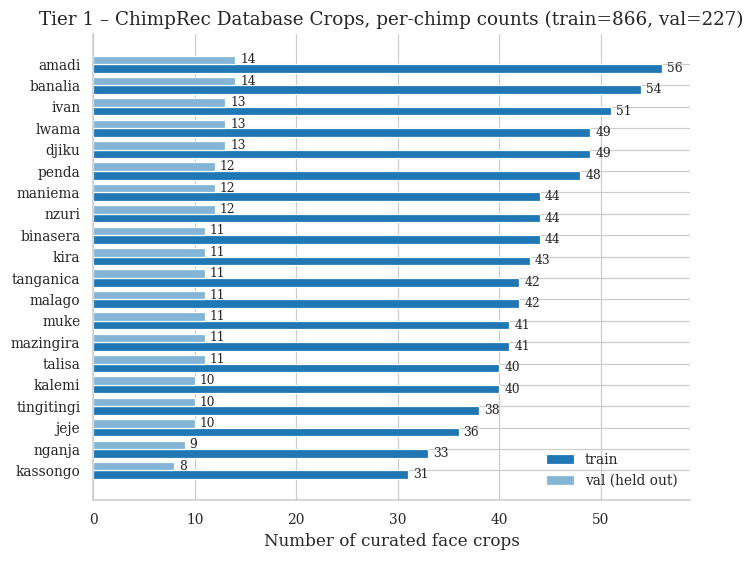

In [95]:
tier1_plot = tier1.sort_values("total", ascending=True)

fig, ax = plt.subplots(figsize=(7.0, 5.5))
y = np.arange(len(tier1_plot))
ax.barh(y - 0.20, tier1_plot["train"], height=0.4, label="train",
        color=TIER_COLORS["Tier 1"])
ax.barh(y + 0.20, tier1_plot["val"],   height=0.4, label="val (held out)",
        color=TIER_COLORS_VAL["Tier 1"])
ax.set_yticks(y)
ax.set_yticklabels(tier1_plot["chimp"])
ax.set_xlabel("Number of curated face crops")
ax.set_title(f"Tier 1 \N{EN DASH} ChimpRec Database Crops, per-chimp counts "
             f"(train={int(tier1['train'].sum())}, val={int(tier1['val'].sum())})")
ax.legend(loc="lower right")
for i, (tr, va) in enumerate(zip(tier1_plot["train"], tier1_plot["val"])):
    ax.text(tr + 0.5, i - 0.20, str(int(tr)), va="center", fontsize=8)
    ax.text(va + 0.5, i + 0.20, str(int(va)), va="center", fontsize=8)
save_fig("tier1_train_val_per_chimp")
plt.show()


## 5.&nbsp; Tier&nbsp;2 &mdash; student manual annotations

Tier&nbsp;2 was assembled by Calogero Montedoro and Brigitte Rezsohazy as
part of the broader annotation campaign described in
§`sec:annotation_workflow`. Crops live in
`student_face_crops/<Name - XX>/`, where `XX` is the two-letter initial
code (`Amadi - AD`, `Kassongo - KG`, &hellip;). The `canonical_name()`
resolver collapses these folder names back to our 20 canonical labels.

This tier is **medium quality**: the crops were extracted from screen
captures and side-channel sources with variable resolution and lighting;
about 5&ndash;10&nbsp;% of them are mis-labelled or include partially
occluded faces. To reflect this, the trainer assigns
$\lambda_2 = 1.5$ (slightly *above* Tier&nbsp;1, because each individual
Tier-2 image is rare and informative) and a sample multiplier
$m_2 = 3$, with a moderate augmentation pipeline (flip, small rotation,
mild colour jitter, light blur).

**How the train/val split was made.** Tier&nbsp;2 has too few images to
afford a separate held-out folder, so the trainer performs a
**deterministic per-chimp split** at load time. The procedure
(implemented in `collect_tier2_split`) is:

1. List Tier-2 images for chimp $c$ and sort them lexicographically.
2. Shuffle the list with `random.Random(seed=42)` (fixed seed).
3. Set $n_{\text{val}}^c = \max\bigl(1, \lfloor 0.15 \cdot |F_c|
   \rceil\bigr)$ if $|F_c| \ge 2$, else $n_{\text{val}}^c = 0$.
4. The first $n_{\text{val}}^c$ shuffled images go to validation, the
   rest to training.

Because the split is per-chimp, every class is guaranteed to appear in
both the train and the val portion, and because the seed is fixed the
split is reproducible across runs. The resulting Tier-2 val set is
folded into the validation loader together with Tier-1 val.



In [96]:
def tier2_split_counts(root: Path, val_fraction: float = 0.15, seed: int = 42) -> pd.DataFrame:
    rng = random.Random(seed)
    rows = []
    per_chimp_files: dict[str, list[Path]] = defaultdict(list)
    if root.exists():
        for d in list_class_dirs(root):
            c = canonical_name(d.name)
            files = sorted(p for p in d.iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS)
            per_chimp_files[c].extend(files)
    for name in CANONICAL_NAMES:
        files = list(per_chimp_files.get(name, []))
        rng.shuffle(files)
        n = len(files)
        n_val = max(1, int(round(n * val_fraction))) if n >= 2 else 0
        rows.append({
            "chimp":   name,
            "n_total": n,
            "n_train": n - n_val,
            "n_val":   n_val,
        })
    return pd.DataFrame(rows)


tier2 = tier2_split_counts(STUDENT_ROOT, val_fraction=0.15, seed=42)
print(f"TIER 2 TOTAL              : {tier2['n_total'].sum()}")
print(f"TIER 2 train portion      : {tier2['n_train'].sum()}")
print(f"TIER 2 val portion (15%)  : {tier2['n_val'].sum()}\n")
tier2.sort_values("n_total", ascending=False).reset_index(drop=True)


TIER 2 TOTAL              : 522
TIER 2 train portion      : 442
TIER 2 val portion (15%)  : 80



,chimp,n_total,n_train,n_val
0,binasera,54,46,8
1,tingitingi,50,42,8
2,kira,49,42,7
3,tanganica,48,41,7
4,muke,47,40,7
5,talisa,45,38,7
6,banalia,37,31,6
7,amadi,25,21,4
8,nzuri,23,20,3
9,kassongo,23,20,3


[fig] results/figures/tier2_student_split_per_chimp.pdf


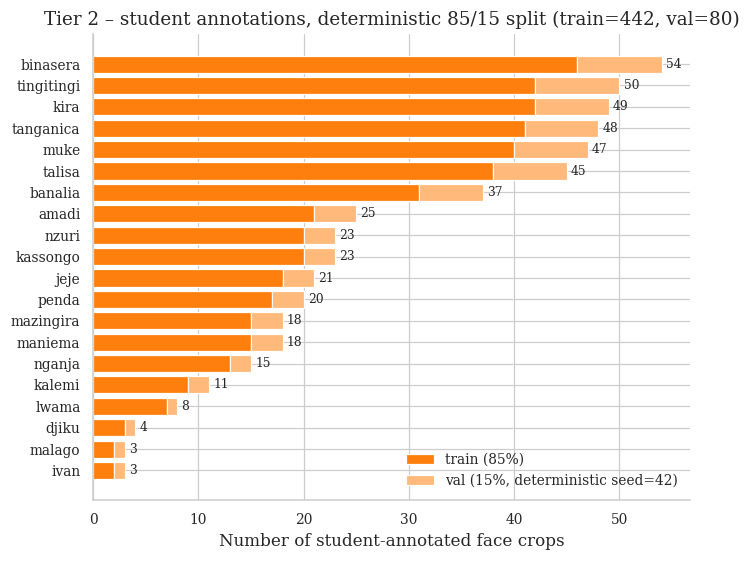

In [97]:
tier2_plot = tier2.sort_values("n_total", ascending=True)

fig, ax = plt.subplots(figsize=(7.0, 5.5))
ax.barh(tier2_plot["chimp"], tier2_plot["n_train"],
        label="train (85%)", color=TIER_COLORS["Tier 2"])
ax.barh(tier2_plot["chimp"], tier2_plot["n_val"], left=tier2_plot["n_train"],
        label="val (15%, deterministic seed=42)", color=TIER_COLORS_VAL["Tier 2"])
ax.set_xlabel("Number of student-annotated face crops")
ax.set_title(f"Tier 2 \N{EN DASH} student annotations, deterministic 85/15 split "
             f"(train={int(tier2['n_train'].sum())}, val={int(tier2['n_val'].sum())})")
ax.legend(loc="lower right")
for i, (n_t, n_v) in enumerate(zip(tier2_plot["n_train"], tier2_plot["n_val"])):
    total = n_t + n_v
    if total > 0:
        ax.text(total + 0.4, i, str(int(total)), va="center", fontsize=8)
save_fig("tier2_student_split_per_chimp")
plt.show()


## 6.&nbsp; Tier&nbsp;3 &mdash; mined face crops from annotated tracking videos

Tier&nbsp;3 is the largest and noisiest tier. It is produced by an
automated mining pipeline that re-uses the named tracking files of
§`sec:hota_data` &mdash; the very same `#`-delimited text format used
for HOTA evaluation, but here the tracker IDs have been replaced by
chimpanzee names by the manual correction step
(§`sec:annotation_workflow`). For each annotated frame we therefore
know **who** is in the body box, and we exploit this free supervision
to mine many additional face crops without any extra manual effort.

Two folders are relevant:

* `face_crops_for_chimpufe/` is the **raw reservoir** produced by the
  mining script before the post-hoc frontal/eye filter. We use it in
  Section&nbsp;8 to study the attrition of the quality cascade.
* `face_crops_frontal_55/` is the **production Tier 3** consumed by the
  fine-tuning script, after the post-hoc filter that requires
  `frontal_score >= 0.55` and at least two visible eyes. It contains
  $\approx$ 18,225 crops over 20 chimps (47 to 3,691 per chimp).

**Train/val split.** Tier&nbsp;3 is **training-only**: validation is
performed exclusively on the curated Tier&nbsp;1 val and the
deterministic Tier&nbsp;2 val portion. Adding noisy mined crops to the
val set would inflate apparent accuracy without measuring anything
useful about real-world performance.

**Imbalance handling.** Rather than capping Tier&nbsp;3 at
$N$ crops/chimp, the production trainer uses two complementary
mechanisms:

1. **Per-image oversampling cap** `--max-resample 3.0`, which iteratively
   clamps each image's expected per-epoch draw count so that no image is
   replicated more than $3\times$. This protects against tiny chimps
   being shown thousands of times, while letting large pools contribute
   their full diversity.
2. A small per-tier loss weight $\lambda_3 = 0.045$ combined with
   $m_3 = 1$ (no extra sampling boost), so Tier&nbsp;3 acts as gentle
   regularisation rather than as a dominant supervision signal.
3. **No augmentation** on Tier&nbsp;3 (`--no-tier3-augmentation`):
   adjacent video frames already provide enormous redundancy, so further
   geometric/colour distortion only pushes the crops outside the
   distribution of recognisable faces.

Section&nbsp;12 quantifies the effect of these choices by computing the
**effective per-tier gradient share** $\rho_t$ that the optimiser
actually sees ($\rho \approx 49.7 / 34.8 / 15.5 \%$).



In [98]:
# Production trainer hyperparameters (mirrors run_finetune_t3_frontal55.slurm)
TIER3_CAP    = 0       # --tier3-max-per-class 0  (no cap)
MAX_RESAMPLE = 3.0     # --max-resample 3.0       (per-image draw cap)

raw_mined  = per_chimp_counts(RAW_MINED_ROOT).rename(columns={"n_images": "raw_mined"})
front_filt = per_chimp_counts(TIER3_ROOT).rename(columns={"n_images": "frontal_55"})
tier3 = raw_mined.merge(front_filt, on="chimp")
# "after_cap" kept for compatibility with downstream cells; with no cap it
# equals frontal_55. The per-image clamp acts on the SAMPLER, not on disk.
tier3["after_cap"] = tier3["frontal_55"]

print(f"Raw video reservoir TOTAL          : {tier3['raw_mined'].sum():,}")
print(f"After frontal_score >= 0.55 + eyes : {tier3['frontal_55'].sum():,}")
print(f"Per-class hard cap                  : {'OFF' if TIER3_CAP == 0 else TIER3_CAP}")
print(f"Per-image expected-draw cap         : {MAX_RESAMPLE} (sampler-level)\n")

tier3.sort_values("frontal_55", ascending=False).reset_index(drop=True)


Raw video reservoir TOTAL          : 30,502
After frontal_score >= 0.55 + eyes : 18,225
Per-class hard cap                  : OFF
Per-image expected-draw cap         : 3.0 (sampler-level)



,chimp,raw_mined,frontal_55,after_cap
0,binasera,6281,3691,3691
1,banalia,4580,2988,2988
2,tingitingi,3246,1778,1778
3,kalemi,1720,1036,1036
4,penda,1453,967,967
5,kira,1431,959,959
6,talisa,1562,922,922
7,muke,2029,921,921
8,malago,1823,900,900
9,amadi,1157,831,831


[fig] results/figures/tier3_raw_vs_filtered_per_chimp.pdf


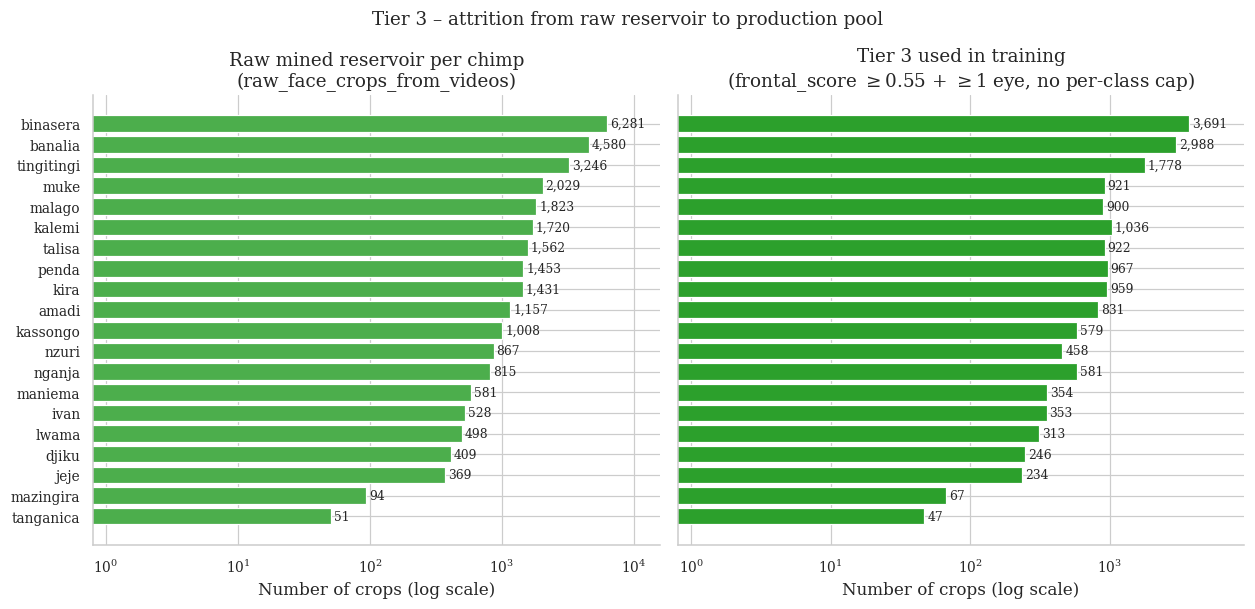

In [99]:
tier3_plot = tier3.sort_values("raw_mined", ascending=True)
y = np.arange(len(tier3_plot))

# Guard against empty/zero columns: log scale crashes on 0 values, so we
# clip-for-display and fall back to linear scale if everything is zero.
def _safe_log_axis(ax, values, label):
    vmax = float(np.max(values)) if len(values) else 0.0
    if vmax > 0:
        ax.set_xscale("log")
        ax.set_xlim(0.8, vmax * 2.5)
    else:
        ax.set_xlim(0, 1)
        ax.text(0.5, 0.5, f"({label} folder is empty\nor not present locally)",
                transform=ax.transAxes, ha="center", va="center",
                fontsize=10, color="firebrick")

raw_vals  = tier3_plot["raw_mined"].to_numpy()
filt_vals = tier3_plot["frontal_55"].to_numpy()
raw_disp  = np.where(raw_vals  > 0, raw_vals,  0.9)
filt_disp = np.where(filt_vals > 0, filt_vals, 0.9)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.6), sharey=True)

ax = axes[0]
ax.barh(y, raw_disp, color=_lighter(TIER_COLORS["Tier 3"], alpha=0.85))
_safe_log_axis(ax, raw_vals, "raw mined reservoir")
ax.set_yticks(y); ax.set_yticklabels(tier3_plot["chimp"])
ax.set_xlabel("Number of crops (log scale)")
ax.set_title("Raw mined reservoir per chimp\n"
             f"({RAW_MINED_ROOT.name})")
for i, v in enumerate(raw_vals):
    ax.text(max(v, 0.9) * 1.05, i, f"{int(v):,}", va="center", fontsize=8)

ax = axes[1]
ax.barh(y, filt_disp, color=TIER_COLORS["Tier 3"])
_safe_log_axis(ax, filt_vals, "frontal_55")
ax.set_xlabel("Number of crops (log scale)")
ax.set_title(r"Tier 3 used in training"
             "\n"
             r"(frontal_score $\geq 0.55$ + $\geq 1$ eye, no per-class cap)")
for i, v in enumerate(filt_vals):
    ax.text(max(v, 0.9) * 1.05, i, f"{int(v):,}", va="center", fontsize=8)

fig.suptitle("Tier 3 \N{EN DASH} attrition from raw reservoir to production pool",
             fontsize=12)
fig.tight_layout()
save_fig("tier3_raw_vs_filtered_per_chimp")
plt.show()


## 8.&nbsp; Quality filtering cascade: acceptance and rejection statistics

The mining script logs every candidate (one per (frame, body-track) pair) into
two CSV side products:

* `accepted_crops.csv` &mdash; one row per saved face crop with its full set of
  quality metrics (`face_conf`, `sharpness`, `brightness`, `contrast`,
  `frontal_score`, `eye_count`, `face_area_ratio`, `face_center_y`);
* `rejected_candidates.csv` &mdash; one row per discarded candidate, with a
  symbolic `reason` field (`no_face_detected`, `no_face_geometry_match`,
  `face_too_small_vs_body`, `blurry`, `low_contrast`, `too_dark`,
  `too_bright`, `bad_aspect`, `not_frontal`, `no_visible_eyes`, …).

The cell below loads whichever of these files are present in the raw mined
folder and computes (i) the global acceptance rate and (ii) the histogram of
rejection reasons. Together these two statistics expose **where in the
cascade the data attrition happens**, which is the key practical insight for
anyone wanting to re-run the pipeline on a new corpus.


In [101]:
def _try_read_csv(path: Path) -> pd.DataFrame | None:
    if path.exists() and path.stat().st_size > 0:
        try:
            return pd.read_csv(path)
        except pd.errors.EmptyDataError:
            return None
    return None


accepted_csv = RAW_MINED_ROOT / "accepted_crops.csv"
rejected_csv = RAW_MINED_ROOT / "rejected_candidates.csv"

accepted_df = _try_read_csv(accepted_csv)
rejected_df = _try_read_csv(rejected_csv)

n_accepted_csv = 0 if accepted_df is None else len(accepted_df)
n_rejected_csv = 0 if rejected_df is None else len(rejected_df)
n_accepted_disk = tier3["raw_mined"].sum()

print(f"accepted_crops.csv      : {n_accepted_csv:,} rows  ({accepted_csv})")
print(f"rejected_candidates.csv : {n_rejected_csv:,} rows  ({rejected_csv})")
print(f"accepted on disk        : {n_accepted_disk:,} files (raw reservoir)")

if accepted_df is None:
    accepted_df = pd.DataFrame()
if rejected_df is None:
    rejected_df = pd.DataFrame()


accepted_crops.csv      : 31,113 rows  (/home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier3/raw_face_crops_from_videos/accepted_crops.csv)
rejected_candidates.csv : 174,355 rows  (/home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier3/raw_face_crops_from_videos/rejected_candidates.csv)
accepted on disk        : 30,502 files (raw reservoir)


Global acceptance rate : 15.14%



[fig] results/figures/rejection_reasons_bar.pdf


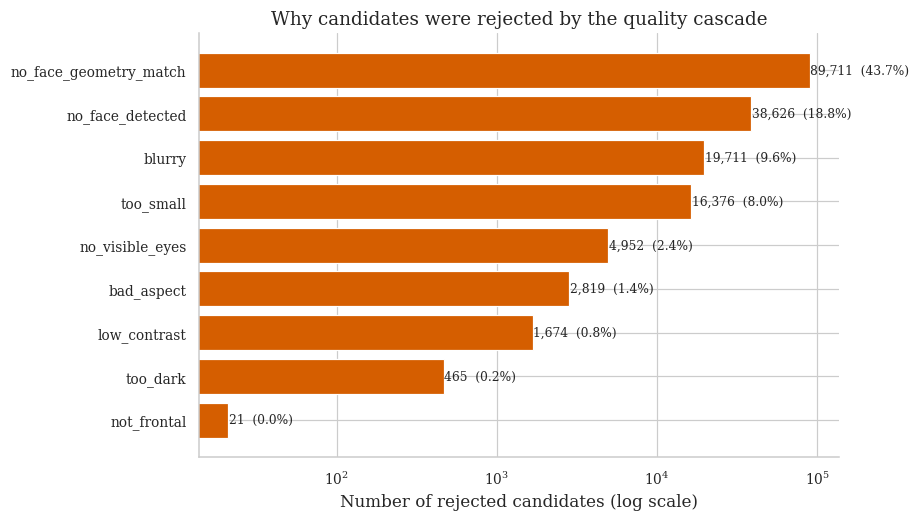

In [102]:
# Order of the cascade (matches process_pair() in the mining script).
CASCADE_REASONS = [
    "invalid_body_bbox",
    "no_face_detected",
    "no_face_geometry_match",
    "invalid_face_crop",
    "face_too_small_vs_body",
    "too_small",
    "bad_aspect",
    "blurry",
    "low_contrast",
    "too_dark",
    "too_bright",
    "not_frontal",
    "no_visible_eyes",
    "save_failed",
]

if not rejected_df.empty:
    reason_counts = rejected_df["reason"].value_counts()
    rejection_table = (reason_counts.reindex(CASCADE_REASONS, fill_value=0)
                                    .reset_index()
                                    .rename(columns={"index": "reason",
                                                     "reason": "count"}))
    rejection_table = rejection_table.rename(columns={
        rejection_table.columns[0]: "reason",
        rejection_table.columns[1]: "count",
    })
    total_seen = n_accepted_csv + n_rejected_csv
    # Rebuild a stable schema to avoid duplicate/misaligned columns.
    rejection_table = pd.DataFrame({
        "reason": CASCADE_REASONS,
        "count": reason_counts.reindex(CASCADE_REASONS, fill_value=0).to_numpy(dtype=int),
    })

    rejection_table["pct_of_candidates"] = (rejection_table["count"] / max(total_seen, 1)) * 100

    print(f"Global acceptance rate : {n_accepted_csv / max(total_seen, 1):.2%}\n")

    fig, ax = plt.subplots(figsize=(7.5, 5.0))
    plot_df = rejection_table[rejection_table["count"] > 0].sort_values("count")
    ax.barh(plot_df["reason"], plot_df["count"], color=sns.color_palette("colorblind")[3])
    for i, (cnt, pct) in enumerate(zip(plot_df["count"], plot_df["pct_of_candidates"])):
        ax.text(cnt * 1.01, i, f"{cnt:,}  ({pct:.1f}%)", va="center", fontsize=8)
    ax.set_xscale("log")
    ax.set_xlabel("Number of rejected candidates (log scale)")
    ax.set_title("Why candidates were rejected by the quality cascade")
    save_fig("rejection_reasons_bar")
    plt.show()

    rejection_table
else:
    print("rejected_candidates.csv is missing or empty &mdash; skipping rejection histogram.")
    rejection_table = pd.DataFrame(columns=["reason", "count", "pct_of_candidates"])
    rejection_table


[fig] results/figures/cascade_waterfall.pdf


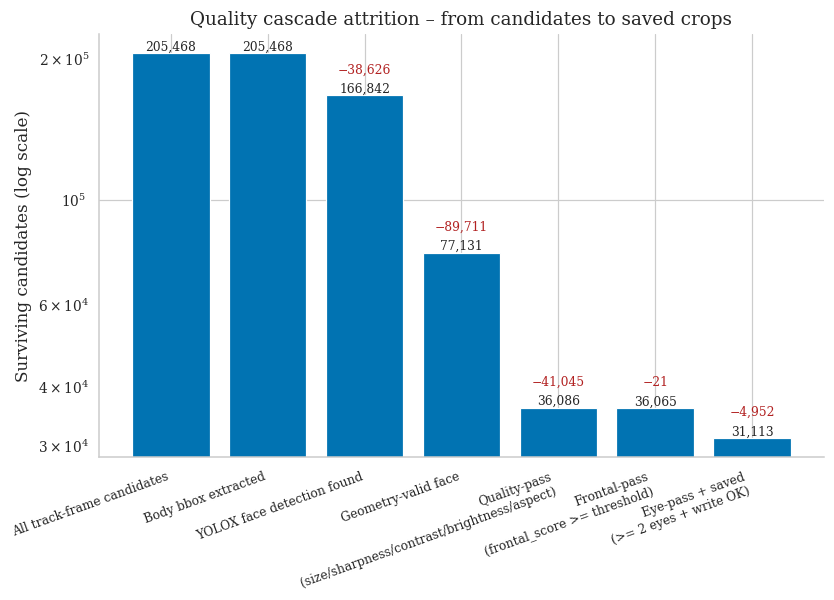

In [103]:
# Waterfall (Sankey-style) attrition chart of the cascade.
GROUPS = [
    ("All track-frame candidates",   {"all"}),
    ("Body bbox extracted",          {"invalid_body_bbox"}),
    ("YOLOX face detection found",   {"no_face_detected"}),
    ("Geometry-valid face",          {"no_face_geometry_match",
                                      "face_too_small_vs_body",
                                      "invalid_face_crop"}),
    ("Quality-pass\n(size/sharpness/contrast/brightness/aspect)",
                                     {"too_small", "bad_aspect", "blurry",
                                      "low_contrast", "too_dark", "too_bright"}),
    ("Frontal-pass\n(frontal_score >= threshold)",
                                     {"not_frontal"}),
    ("Eye-pass + saved\n(>= 2 eyes + write OK)",
                                     {"no_visible_eyes", "save_failed"}),
]

if not rejected_df.empty:
    total = n_accepted_csv + n_rejected_csv
    reason_counter = Counter(rejected_df["reason"])

    surviving = total
    waterfall_rows = [{"stage": GROUPS[0][0], "surviving": total, "lost_here": 0}]
    for stage_name, lost_set in GROUPS[1:]:
        lost_here = sum(reason_counter.get(r, 0) for r in lost_set)
        surviving = max(0, surviving - lost_here)
        waterfall_rows.append({"stage": stage_name,
                               "surviving": surviving,
                               "lost_here": lost_here})
    waterfall = pd.DataFrame(waterfall_rows)

    fig, ax = plt.subplots(figsize=(8.5, 5.0))
    bars  = ax.bar(np.arange(len(waterfall)), waterfall["surviving"],
                   color=sns.color_palette("colorblind")[0])
    for i, row in waterfall.iterrows():
        ax.text(i, row["surviving"], f"{int(row['surviving']):,}",
                ha="center", va="bottom", fontsize=8)
        if row["lost_here"]:
            ax.text(i, row["surviving"] * 1.10 if row["surviving"] > 0 else 1,
                    f"\N{MINUS SIGN}{int(row['lost_here']):,}",
                    ha="center", va="bottom", fontsize=8, color="firebrick")
    ax.set_yscale("log")
    ax.set_xticks(np.arange(len(waterfall)))
    ax.set_xticklabels(waterfall["stage"], rotation=20, ha="right", fontsize=8)
    ax.set_ylabel("Surviving candidates (log scale)")
    ax.set_title("Quality cascade attrition \N{EN DASH} from candidates to saved crops")
    save_fig("cascade_waterfall")
    plt.show()

    waterfall["surv_pct_of_input"] = waterfall["surviving"] / max(total, 1) * 100
    waterfall
else:
    print("Skipping waterfall (no rejected_candidates.csv).")
    waterfall = pd.DataFrame(columns=["stage", "surviving", "lost_here", "surv_pct_of_input"])
    waterfall


## 9.&nbsp; Frontal-face and eye-visibility heuristics

Generic OpenCV face/eye detectors are trained on humans and behave poorly
on dark, hairy chimpanzee faces. We therefore replace them with two
chimp-specific heuristics implemented inside
`extract_face_crops_from_named_tracks.py`:

**Frontal score** &mdash; a weighted sum of five sub-scores in $[0, 1]$:

$$
\text{frontal\_score} =
0.40\,\underbrace{\text{sym}_{\text{LR}}}_{\substack{\text{normalised}\\ \text{cross-corr.}\\ \text{of left and}\\ \text{flipped right halves}}}
+ 0.25\,\underbrace{\text{skin\_patch}}_{\substack{\text{inner-ellipse}\\ \text{vs outer-ring}\\ \text{brightness gap}\\ \text{(chimp-specific)}}}
+ 0.15\,\text{grad\_balance}
+ 0.12\,\text{centre\_score}
+ 0.08\,\text{bright\_balance}.
$$

The chimp-specific term captures the fact that a frontal chimpanzee face
exposes a brighter pinkish/tan central skin patch (muzzle and brow
region) surrounded by darker fur. In profile or back views this contrast
collapses, so the term is a strong cue for camera-facing pose. The
weights were chosen empirically on a few hundred crops and the
production acceptance threshold is `min_front_score = 0.55`. Earlier
experiments used the more conservative cut-off 0.65; we relaxed it to
0.55 because the per-image oversampling cap (`--max-resample 3.0`)
already prevents any individual frame from dominating the optimiser.

**Eye-visibility** &mdash; the ROI is restricted to the upper $50\%$ of
the face, contrast-enhanced with CLAHE, and thresholded at the 6th
percentile of its grey distribution. Connected components that look like
eye-sized round dark blobs are then paired between the left and right
halves of the ROI, and a pair is accepted only when the two blobs are
roughly level ($|\Delta y| \le 0.18\,h_{\text{ROI}}$) and meaningfully
separated. The detector returns 0, 1 or 2 visible eyes; Tier&nbsp;3
keeps only crops with **at least 1 visible eyes**.

The two histograms below visualise these scores on the accepted pool.
The acceptance thresholds are marked as vertical lines.



[fig] results/figures/frontal_score_eye_count_histograms.pdf


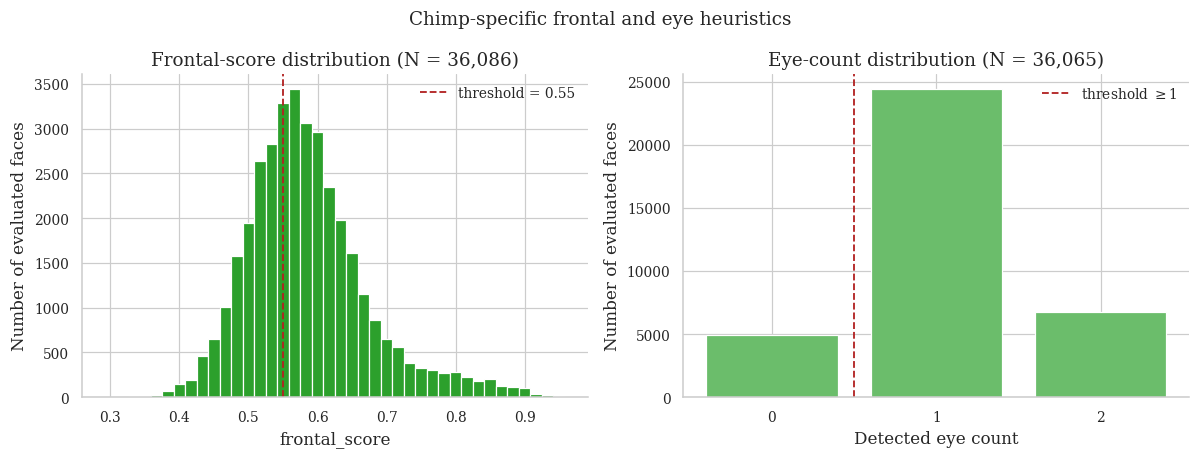

In [104]:
MIN_FRONT_SCORE = 0.55     # production threshold for Tier 3
MIN_EYE_COUNT   = 1

# Pool together accepted + rejected rows that carry a frontal_score, so the
# histogram covers the full distribution of *evaluated* faces, not only the
# accepted ones.
front_scores = []
eye_counts   = []

for df in (accepted_df, rejected_df):
    if df.empty:
        continue
    if "frontal_score" in df.columns:
        front_scores.append(pd.to_numeric(df["frontal_score"], errors="coerce").dropna().values)
    if "eye_count" in df.columns:
        eye_counts.append(pd.to_numeric(df["eye_count"], errors="coerce").dropna().astype(int).values)

front_scores = np.concatenate(front_scores) if front_scores else np.array([])
eye_counts   = np.concatenate(eye_counts)   if eye_counts   else np.array([])

if front_scores.size == 0 and eye_counts.size == 0:
    print("No frontal_score / eye_count columns found in the CSVs; skipping histograms.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2))

    ax = axes[0]
    if front_scores.size:
        ax.hist(front_scores, bins=40, color=TIER_COLORS["Tier 3"], edgecolor="white")
        ax.axvline(MIN_FRONT_SCORE, color="firebrick", linestyle="--",
                   label=f"threshold = {MIN_FRONT_SCORE:.2f}")
        ax.set_xlabel("frontal_score")
        ax.set_ylabel("Number of evaluated faces")
        ax.set_title(f"Frontal-score distribution (N = {front_scores.size:,})")
        ax.legend()
    else:
        ax.text(0.5, 0.5, "no frontal_score column", ha="center", va="center")

    ax = axes[1]
    if eye_counts.size:
        unique, counts = np.unique(eye_counts, return_counts=True)
        ax.bar(unique, counts, color=_lighter(TIER_COLORS["Tier 3"], alpha=0.7),
               edgecolor="white")
        ax.axvline(MIN_EYE_COUNT - 0.5, color="firebrick", linestyle="--",
                   label=f"threshold $\\geq {MIN_EYE_COUNT}$")
        ax.set_xlabel("Detected eye count")
        ax.set_ylabel("Number of evaluated faces")
        ax.set_title(f"Eye-count distribution (N = {eye_counts.size:,})")
        ax.set_xticks(sorted(unique))
        ax.legend()
    else:
        ax.text(0.5, 0.5, "no eye_count column", ha="center", va="center")

    fig.suptitle("Chimp-specific frontal and eye heuristics", fontsize=12)
    fig.tight_layout()
    save_fig("frontal_score_eye_count_histograms")
    plt.show()


## 10.&nbsp; Combined three-tier dataset &mdash; aggregate counts

We now combine the three tiers as the production trainer actually
consumes them: Tier&nbsp;1 train (807 images) + Tier&nbsp;2 train (the
85% portion of the deterministic split) + Tier&nbsp;3 train (the entire
post-filter pool, no per-class cap, with the per-image
`--max-resample 3.0` clamp applied at sampler level). Validation pools
together Tier&nbsp;1 val (217 images) and the Tier&nbsp;2 val portion;
Tier&nbsp;3 is **train only**.

The resulting table is the canonical summary of the supervised dataset
and is intended to be lifted verbatim into the LaTeX manuscript.



In [105]:
# Production hyperparameters (mirrors run_finetune_t3_frontal55.slurm).
TIER_LOSS_W = {1: 1.000, 2: 1.500, 3: 0.045}
TIER_SAMP_M = {1: 5,     2: 3,     3: 1    }

combined = pd.DataFrame({
    "chimp":        CANONICAL_NAMES,
    "tier1_train":  tier1.set_index("chimp").loc[CANONICAL_NAMES, "train"].values,
    "tier1_val":    tier1.set_index("chimp").loc[CANONICAL_NAMES, "val"].values,
    "tier2_train":  tier2.set_index("chimp").loc[CANONICAL_NAMES, "n_train"].values,
    "tier2_val":    tier2.set_index("chimp").loc[CANONICAL_NAMES, "n_val"].values,
    "tier3_train":  tier3.set_index("chimp").loc[CANONICAL_NAMES, "frontal_55"].values,
})
combined["train_total"] = (combined["tier1_train"]
                           + combined["tier2_train"]
                           + combined["tier3_train"])
combined["val_total"]   = combined["tier1_val"] + combined["tier2_val"]
combined = combined.sort_values("train_total", ascending=False).reset_index(drop=True)

per_tier_summary = pd.DataFrame([
    {"tier": "Tier 1 (curated)",        "split": "train",
     "n_images": int(combined["tier1_train"].sum()),
     "loss_weight": TIER_LOSS_W[1], "sample_mult": TIER_SAMP_M[1]},
    {"tier": "Tier 1 (curated)",        "split": "val",
     "n_images": int(combined["tier1_val"].sum()),
     "loss_weight": float("nan"),  "sample_mult": float("nan")},
    {"tier": "Tier 2 (student)",        "split": "train",
     "n_images": int(combined["tier2_train"].sum()),
     "loss_weight": TIER_LOSS_W[2], "sample_mult": TIER_SAMP_M[2]},
    {"tier": "Tier 2 (student)",        "split": "val",
     "n_images": int(combined["tier2_val"].sum()),
     "loss_weight": float("nan"),  "sample_mult": float("nan")},
    {"tier": "Tier 3 (video, frontal>=0.55)", "split": "train",
     "n_images": int(combined["tier3_train"].sum()),
     "loss_weight": TIER_LOSS_W[3], "sample_mult": TIER_SAMP_M[3]},
])

per_tier_stats = pd.DataFrame({
    "tier": ["Tier 1 train", "Tier 2 train", "Tier 3 train"],
    "n_classes": [int((combined["tier1_train"] > 0).sum()),
                  int((combined["tier2_train"] > 0).sum()),
                  int((combined["tier3_train"] > 0).sum())],
    "mean_per_class": [combined["tier1_train"].mean(),
                       combined["tier2_train"].mean(),
                       combined["tier3_train"].mean()],
    "std_per_class":  [combined["tier1_train"].std(),
                       combined["tier2_train"].std(),
                       combined["tier3_train"].std()],
    "min_per_class":  [combined["tier1_train"].min(),
                       combined["tier2_train"].min(),
                       combined["tier3_train"].min()],
    "max_per_class":  [combined["tier1_train"].max(),
                       combined["tier2_train"].max(),
                       combined["tier3_train"].max()],
}).round(2)

print("Per-tier headline counts:")
display(per_tier_summary)
print("\nPer-class statistics:")
display(per_tier_stats)
print(f"\nGrand training total : {int(combined['train_total'].sum()):,} images")
print(f"Grand val      total : {int(combined['val_total'].sum()):,} images")


Per-tier headline counts:


,tier,split,n_images,loss_weight,sample_mult
0,Tier 1 (curated),train,866,1.000,5.0
1,Tier 1 (curated),val,227,NaN,NaN
2,Tier 2 (student),train,442,1.500,3.0
3,Tier 2 (student),val,80,NaN,NaN
4,"Tier 3 (video, frontal>=0.55)",train,18225,0.045,1.0



Per-class statistics:


,tier,n_classes,mean_per_class,std_per_class,min_per_class,max_per_class
0,Tier 1 train,20,43.30,6.48,31,56
1,Tier 2 train,20,22.10,14.84,2,46
2,Tier 3 train,20,911.25,934.28,47,3691



Grand training total : 19,533 images
Grand val      total : 307 images


## 11.&nbsp; Per-class training composition (stacked bar)

The figure below shows, for each chimpanzee, how its training pool is
composed across the three tiers after the cap is applied. This is the
single most informative diagnostic of dataset balance: chimps whose bar
is dominated by Tier&nbsp;1 (curated) enjoy clean supervision; chimps
whose bar relies heavily on Tier&nbsp;3 (capped video crops) are
inherently noisier targets, which is reflected later in the per-class
accuracies reported by the evaluation notebook.


[fig] results/figures/per_chimp_tier_composition_stacked.pdf


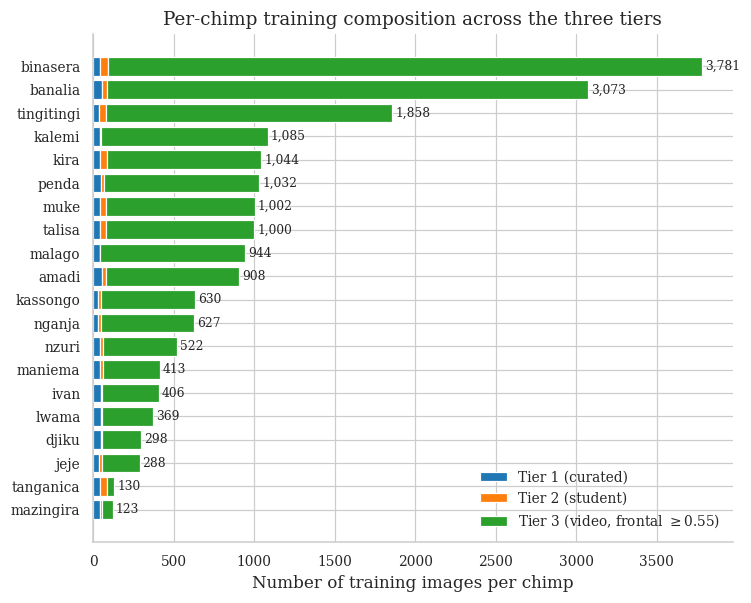

In [106]:
stacked = combined.sort_values("train_total", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 6.0))
left = np.zeros(len(stacked))
for col, label, colour in [
    ("tier1_train", "Tier 1 (curated)",                TIER_COLORS["Tier 1"]),
    ("tier2_train", "Tier 2 (student)",                TIER_COLORS["Tier 2"]),
    ("tier3_train", r"Tier 3 (video, frontal $\geq 0.55$)", TIER_COLORS["Tier 3"]),
]:
    ax.barh(stacked["chimp"], stacked[col], left=left, label=label, color=colour)
    left = left + stacked[col].values

for i, total in enumerate(stacked["train_total"]):
    ax.text(total + max(left) * 0.005, i, f"{int(total):,}", va="center", fontsize=8)

ax.set_xlabel("Number of training images per chimp")
ax.set_title("Per-chimp training composition across the three tiers")
ax.legend(loc="lower right")
save_fig("per_chimp_tier_composition_stacked")
plt.show()


## 12.&nbsp; Class imbalance and the sampling/loss-weighting strategy

The supervised pool spans three orders of magnitude (Tier&nbsp;1 has
$\sim 40$ images per chimp, Tier&nbsp;3 has up to $\sim 3{,}700$), and
within the same chimp the three tiers carry very different reliabilities.
The training script addresses both axes simultaneously through the
`WeightedRandomSampler`:

$$
w_{i} \;=\; \underbrace{\dfrac{1}{n_{c(i)}}}_{\text{class-balance term}}
            \;\times\; \underbrace{m_{t(i)}}_{\text{tier multiplier}},
$$

where $n_{c}$ is the total number of training images of class $c$ across
**all** tiers and $m_t \in \{5, 3, 1\}$ for tiers 1/2/3 respectively. On
top of that, the per-sample cross-entropy loss is multiplied by a
per-tier loss weight $\lambda_t \in \{1.0, 1.5, 0.045\}$, so the
expected per-image contribution to the gradient scales as
$w_i \cdot \lambda_{t(i)}$.

**Within-tier imbalance is handled by the term $1/n_c$.** Because $n_c$
counts images of chimp $c$ across all tiers, every chimp has the *same*
expected per-tier draw frequency regardless of how many raw images that
chimp contributes. A chimp with only 30 Tier-3 frames is therefore
sampled just as often as a chimp with 3,000 Tier-3 frames, the only
difference being which physical file is drawn each time.

**Per-image oversampling cap.** For tiny Tier-1 classes the term
$m_1 / n_c$ can cause the same image to be drawn dozens of times per
epoch. The trainer caps this with `--max-resample 3.0`, which iteratively
clamps individual sample weights so that no image is drawn more than
$3\times$ in expectation per epoch. The clamp is *applied to the
sampler*, not to the dataset on disk, so the augmentation pipeline still
sees fresh transforms on each draw.

**Effective per-tier gradient share.** Combining $w_i$ and $\lambda_t$,
the expected fraction of the gradient norm contributed by tier $t$ is

$$
\rho_t \;=\; \dfrac{\lambda_t \sum_{i \in t} w_i}
                   {\sum_{t'} \lambda_{t'} \sum_{i \in t'} w_i}.
$$

With the production hyperparameters this gives
$\rho \approx 49.7\,/\,34.8\,/\,15.5\,\%$ for tiers 1/2/3 respectively
&mdash; i.e. the curated tier still dominates the optimiser even though
it represents less than 5 % of the raw training images. The two heatmaps
plus the bar chart below visualise this in three complementary views.



[fig] results/figures/sampling_and_loss_heatmaps.pdf


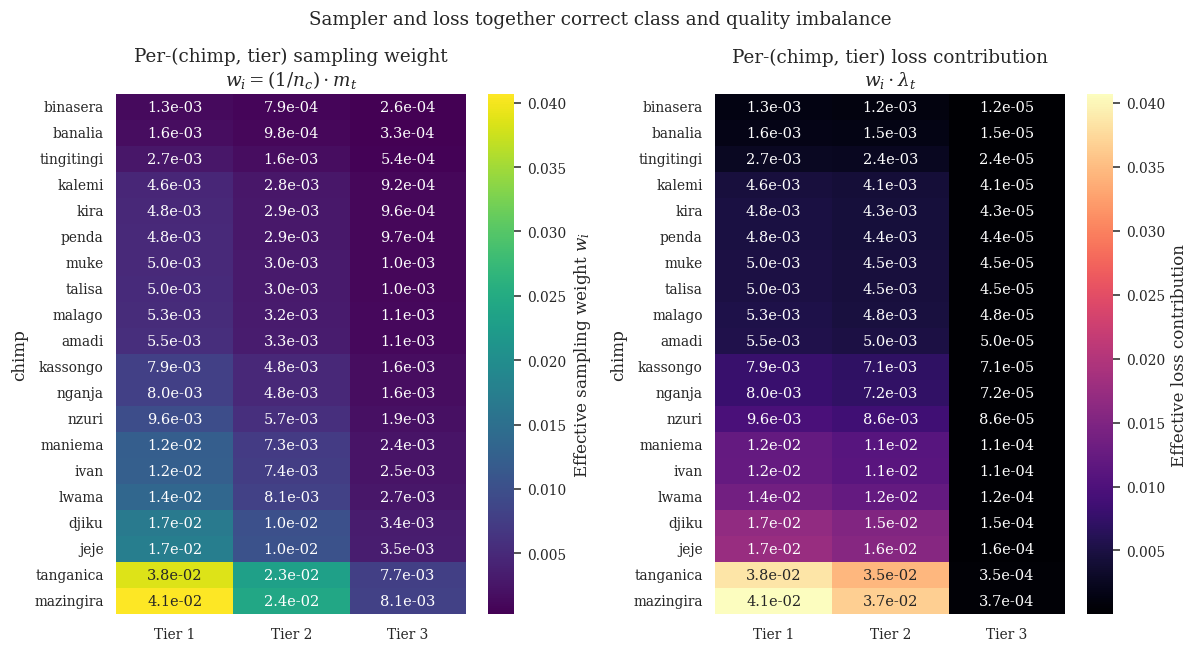

In [107]:
# Per-(chimp, tier) effective sampling weight w_i and loss contribution w_i * lambda_t
class_total = combined["train_total"].values  # n_c

per_cell_weight = pd.DataFrame(index=combined["chimp"], columns=["Tier 1", "Tier 2", "Tier 3"], dtype=float)
per_cell_loss   = pd.DataFrame(index=combined["chimp"], columns=["Tier 1", "Tier 2", "Tier 3"], dtype=float)
for tier_idx, (tier_label, col_name) in enumerate(
        [("Tier 1", "tier1_train"), ("Tier 2", "tier2_train"), ("Tier 3", "tier3_train")], start=1):
    n_tier = combined[col_name].values
    has = n_tier > 0
    w = np.zeros(len(combined))
    w[has] = (1.0 / class_total[has]) * TIER_SAMP_M[tier_idx]
    per_cell_weight[tier_label] = w
    per_cell_loss[tier_label]   = w * TIER_LOSS_W[tier_idx]

# Sort chimps by total training count (descending, like the stacked bar)
order = combined.sort_values("train_total", ascending=False)["chimp"].tolist()
per_cell_weight = per_cell_weight.loc[order]
per_cell_loss   = per_cell_loss.loc[order]

fig, axes = plt.subplots(1, 2, figsize=(11.0, 6.0))
sns.heatmap(per_cell_weight, annot=True, fmt=".1e", cmap="viridis",
            cbar_kws={"label": "Effective sampling weight $w_i$"}, ax=axes[0])
axes[0].set_title("Per-(chimp, tier) sampling weight\n$w_i = (1/n_c) \\cdot m_t$")
axes[0].set_xlabel("")

sns.heatmap(per_cell_loss, annot=True, fmt=".1e", cmap="magma",
            cbar_kws={"label": "Effective loss contribution"}, ax=axes[1])
axes[1].set_title("Per-(chimp, tier) loss contribution\n$w_i \\cdot \\lambda_t$")
axes[1].set_xlabel("")

fig.suptitle("Sampler and loss together correct class and quality imbalance",
             fontsize=12)
fig.tight_layout()
save_fig("sampling_and_loss_heatmaps")
plt.show()


Total training images          : 19,533
Images clamped by --max-resample=3.0 : 1,501  (7.7%)
Max expected draws / image after clamp : 3.000

rho_t WITHOUT clamp (misleading: ignores --max-resample):
  Tier 1: rho = 66.36 %   (lambda=1.0, m=5, sum_w=9.291)
  Tier 2: rho = 28.09 %   (lambda=1.5, m=3, sum_w=2.622)
  Tier 3: rho =  5.55 %   (lambda=0.045, m=1, sum_w=17.268)

rho_t WITH clamp (matches what the optimiser actually sees):
  Tier 1: rho = 51.00 %   (lambda=1.0, m=5, sum_w=2.512)
  Tier 2: rho = 33.87 %   (lambda=1.5, m=3, sum_w=1.112)
  Tier 3: rho = 15.13 %   (lambda=0.045, m=1, sum_w=16.565)
  Sum check : 100.00 %

[fig] results/figures/per_tier_gradient_share.pdf


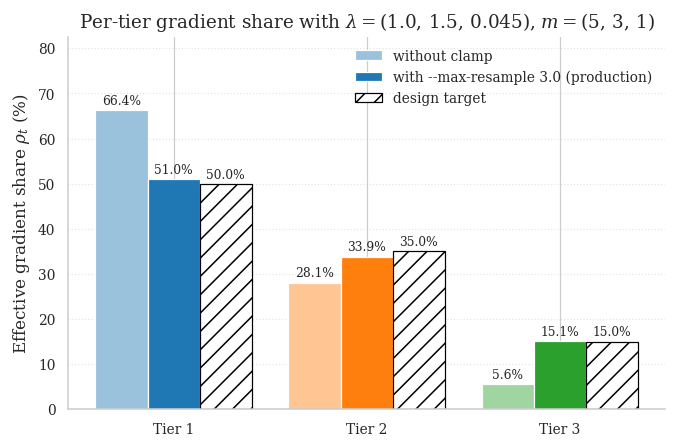

In [108]:
# ---------------------------------------------------------------------------
# Effective per-tier gradient share rho_t.
#
# The mathematical formula is
#     rho_t = (lambda_t * sum_{i in t} w_i) / sum_{t'} (lambda_{t'} * sum_{i in t'} w_i)
# but the per-image weight w_i that the trainer actually uses is NOT the raw
#     w_i^raw = (1 / n_c) * m_t
# It is the iteratively CLAMPED weight produced by build_combined_sampler
# with --max-resample 3.0:
#
#     for _ in range(50):
#         expected = n * w / w.sum()
#         over     = expected > max_resample
#         if not over.any(): break
#         w[over] *= max_resample / expected[over]
#
# Without the clamp, tiny Tier-1 classes (a few dozen images) would each be
# drawn ~40 times per epoch, which is exactly what we want to prevent. The
# clamp pushes those weights down and, by reducing sum(w), implicitly
# rebalances the three tiers. Reporting the un-clamped rho_t is therefore
# misleading: it overstates Tier 1 (whose tiny classes carry huge raw
# weights) and ignores how the clamp redistributes mass across tiers.
#
# We compute BOTH versions below so the impact of the clamp is visible.
# ---------------------------------------------------------------------------

def _build_per_image_weights() -> tuple[np.ndarray, np.ndarray]:
    """Reconstruct the trainer's per-image (weight, tier) arrays from disk counts.

    Returns
    -------
    raw_w : (N,) array of raw per-image weights w_i = (1/n_c) * m_t
    tiers : (N,) array of tier ids in {1, 2, 3}
    """
    raw_w_list, tier_list = [], []
    name_to_tot = dict(zip(combined["chimp"], combined["train_total"]))
    for tier_idx, col in [(1, "tier1_train"), (2, "tier2_train"), (3, "tier3_train")]:
        m_t = TIER_SAMP_M[tier_idx]
        for _, row in combined.iterrows():
            n_c     = name_to_tot[row["chimp"]]
            n_tier  = int(row[col])
            if n_c == 0 or n_tier == 0:
                continue
            w_i = (1.0 / n_c) * m_t
            raw_w_list.extend([w_i] * n_tier)
            tier_list.extend([tier_idx] * n_tier)
    return np.asarray(raw_w_list, dtype=np.float64), np.asarray(tier_list, dtype=np.int64)


def _apply_max_resample_clamp(w: np.ndarray, max_resample: float, n_iter: int = 50) -> np.ndarray:
    """Mirror build_combined_sampler's iterative clamp."""
    w = w.copy()
    n = len(w)
    for _ in range(n_iter):
        expected = n * w / w.sum()
        over = expected > max_resample
        if not over.any():
            break
        w[over] *= max_resample / expected[over]
    return w


def _rho_from_weights(w: np.ndarray, tiers: np.ndarray) -> dict[int, float]:
    sums   = {t: w[tiers == t].sum() for t in (1, 2, 3)}
    weighted = {t: TIER_LOSS_W[t] * sums[t] for t in (1, 2, 3)}
    denom = sum(weighted.values())
    return {t: weighted[t] / denom for t in (1, 2, 3)}, sums


raw_w, tiers_arr = _build_per_image_weights()
clamped_w        = _apply_max_resample_clamp(raw_w, MAX_RESAMPLE)

rho_unclamped, sums_unclamped = _rho_from_weights(raw_w,     tiers_arr)
rho_clamped,   sums_clamped   = _rho_from_weights(clamped_w, tiers_arr)

# Diagnostics: how many images were clamped, and the resulting per-image cap
n_total       = len(raw_w)
n_clamped     = int((clamped_w < raw_w - 1e-12).sum())
expected_post = n_total * clamped_w / clamped_w.sum()
print(f"Total training images          : {n_total:,}")
print(f"Images clamped by --max-resample={MAX_RESAMPLE} : {n_clamped:,}"
      f"  ({n_clamped / n_total * 100:.1f}%)")
print(f"Max expected draws / image after clamp : {expected_post.max():.3f}\n")

print("rho_t WITHOUT clamp (misleading: ignores --max-resample):")
for t in (1, 2, 3):
    print(f"  Tier {t}: rho = {rho_unclamped[t]*100:5.2f} %"
          f"   (lambda={TIER_LOSS_W[t]}, m={TIER_SAMP_M[t]}, "
          f"sum_w={sums_unclamped[t]:.3f})")

print("\nrho_t WITH clamp (matches what the optimiser actually sees):")
for t in (1, 2, 3):
    print(f"  Tier {t}: rho = {rho_clamped[t]*100:5.2f} %"
          f"   (lambda={TIER_LOSS_W[t]}, m={TIER_SAMP_M[t]}, "
          f"sum_w={sums_clamped[t]:.3f})")
print(f"  Sum check : {sum(rho_clamped.values())*100:.2f} %\n")

# Bar chart: side-by-side rho_t with and without clamp, vs target 50/35/15.
target = {1: 50.0, 2: 35.0, 3: 15.0}
labels = [f"Tier {t}" for t in (1, 2, 3)]
x = np.arange(len(labels))
width = 0.27

fig, ax = plt.subplots(figsize=(7.0, 4.4))
bars_unc = ax.bar(x - width, [rho_unclamped[t]*100 for t in (1,2,3)], width,
                  label="without clamp",
                  color=[_lighter(TIER_COLORS[l], alpha=0.45) for l in labels])
bars_cl  = ax.bar(x,         [rho_clamped[t]*100   for t in (1,2,3)], width,
                  label=f"with --max-resample {MAX_RESAMPLE} (production)",
                  color=[TIER_COLORS[l] for l in labels])
bars_tg  = ax.bar(x + width, [target[t]            for t in (1,2,3)], width,
                  label="design target",
                  color="white", edgecolor="black", hatch="//")

for bars in (bars_unc, bars_cl, bars_tg):
    for bar in bars:
        v = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.6, f"{v:.1f}%",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel(r"Effective gradient share $\rho_t$ (%)")
ax.set_ylim(0, max(70, max(rho_unclamped.values())*100) * 1.18)
ax.set_title(r"Per-tier gradient share with $\lambda = (1.0,\,1.5,\,0.045)$, "
             r"$m = (5,\,3,\,1)$")
ax.legend(loc="upper right")
ax.grid(axis="y", linestyle=":", alpha=0.5)
save_fig("per_tier_gradient_share")
plt.show()


## 13.&nbsp; Train / val / test split audit and data-leakage check

The held-out test set lives in `face_recognition_db/test/` as a flat
folder of files of the form `AD1.png`, `BL3.png`, ... where the alphabetic
prefix encodes the chimpanzee identity through `INITIAL_TO_NAME`. The
fine-tuning script enforces a strict separation: **no test file may
appear in the training pool nor in the validation pool**. We re-run that
check here, and additionally verify that every canonical chimp class
appears in train, val and test.


Test files          : 500
  resolved by code  : 500
  unresolved prefix : 0



Data-leakage check : PASSED  (19,840 train/val files scanned, none of them appear in test/)
[fig] results/figures/test_set_per_chimp.pdf


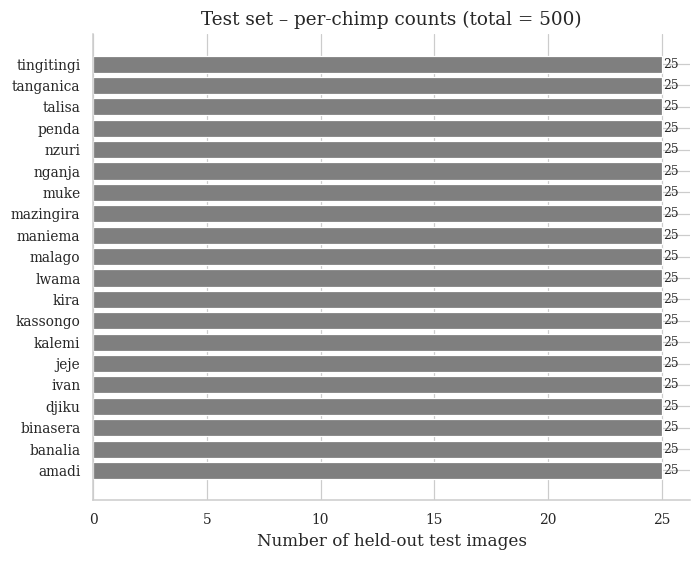

In [109]:
def name_from_test_filename(fname: str) -> str | None:
    stem = Path(fname).stem
    code = "".join(ch for ch in stem if ch.isalpha()).upper()
    for k in sorted(INITIAL_TO_NAME.keys(), key=len, reverse=True):
        if code.startswith(k):
            return INITIAL_TO_NAME[k]
    return None


# Test inventory
test_files = sorted(p for p in TEST_ROOT.iterdir()
                    if p.is_file() and p.suffix.lower() in IMG_EXTS) if TEST_ROOT.exists() else []
test_per_chimp = Counter(name_from_test_filename(p.name) for p in test_files)
test_resolved = {k: v for k, v in test_per_chimp.items() if k is not None}
test_unresolved = test_per_chimp.get(None, 0)
print(f"Test files          : {len(test_files)}")
print(f"  resolved by code  : {sum(test_resolved.values())}")
print(f"  unresolved prefix : {test_unresolved}\n")

# Leakage check across the four production training/val folders
test_names_set = {p.name for p in test_files}
all_train_val_paths = []
for root in (TRAIN_ROOT, VAL_ROOT, STUDENT_ROOT, TIER3_ROOT):
    if root.exists():
        for d in list_class_dirs(root):
            all_train_val_paths.extend(p for p in d.iterdir()
                                       if p.is_file() and p.suffix.lower() in IMG_EXTS)
leaked = [p for p in all_train_val_paths if p.name in test_names_set]
if leaked:
    print(f"DATA-LEAKAGE CHECK : FAILED ({len(leaked)} files)")
    for p in leaked[:10]:
        print("  ", p)
else:
    print(f"Data-leakage check : PASSED  ({len(all_train_val_paths):,} train/val files scanned, "
          f"none of them appear in test/)")

# Per-tier test-set bar chart (held out, never seen during training)
test_df = pd.DataFrame(
    [{"chimp": name, "n_test": int(test_resolved.get(name, 0))} for name in CANONICAL_NAMES]
).sort_values("n_test", ascending=True)

fig, ax = plt.subplots(figsize=(7.0, 5.5))
ax.barh(test_df["chimp"], test_df["n_test"], color=TIER_COLORS["Test"])
for i, v in enumerate(test_df["n_test"]):
    if v > 0:
        ax.text(v + 0.05, i, str(int(v)), va="center", fontsize=8)
ax.set_xlabel("Number of held-out test images")
ax.set_title(f"Test set \N{EN DASH} per-chimp counts (total = {len(test_files)})")
save_fig("test_set_per_chimp")
plt.show()


In [110]:
# Per-chimp coverage table
coverage_rows = []
for name in CANONICAL_NAMES:
    coverage_rows.append({
        "chimp":      name,
        "in_train_t1": int(combined.loc[combined["chimp"] == name, "tier1_train"].iat[0] > 0),
        "in_val_t1":   int(combined.loc[combined["chimp"] == name, "tier1_val"].iat[0]   > 0),
        "in_train_t2": int(combined.loc[combined["chimp"] == name, "tier2_train"].iat[0] > 0),
        "in_val_t2":   int(combined.loc[combined["chimp"] == name, "tier2_val"].iat[0]   > 0),
        "in_tier3":    int(combined.loc[combined["chimp"] == name, "tier3_train"].iat[0] > 0),
        "in_test":     int(test_resolved.get(name, 0) > 0),
        "n_test":      int(test_resolved.get(name, 0)),
    })
coverage = pd.DataFrame(coverage_rows)

missing_in_test = coverage[coverage["in_test"] == 0]["chimp"].tolist()
missing_in_t1   = coverage[coverage["in_train_t1"] == 0]["chimp"].tolist()
print("Chimps missing from train Tier 1 :", missing_in_t1 or "none")
print("Chimps missing from test         :", missing_in_test or "none")
coverage


Chimps missing from train Tier 1 : none
Chimps missing from test         : none


,chimp,in_train_t1,in_val_t1,in_train_t2,in_val_t2,in_tier3,in_test,n_test
0,amadi,1,1,1,1,1,1,25
1,banalia,1,1,1,1,1,1,25
2,binasera,1,1,1,1,1,1,25
3,djiku,1,1,1,1,1,1,25
4,ivan,1,1,1,1,1,1,25
5,jeje,1,1,1,1,1,1,25
6,kalemi,1,1,1,1,1,1,25
7,kassongo,1,1,1,1,1,1,25
8,kira,1,1,1,1,1,1,25
9,lwama,1,1,1,1,1,1,25


## 14.&nbsp; Augmentation strategy per tier &mdash; visual examples

Each tier is paired with a different `torchvision` augmentation pipeline,
matching the philosophy that *the noisier the source, the milder the
augmentation*:

* **Tier&nbsp;1 (heavy).** RandomResizedCrop, rotation up to 15&deg;,
  perspective, colour jitter, gaussian blur, random grayscale, random
  erasing.
* **Tier&nbsp;2 (moderate).** Resize, horizontal flip, small rotation,
  modest colour jitter, mild blur.
* **Tier&nbsp;3 (minimal).** Resize and horizontal flip only.

The grid below applies each pipeline `k=8` times to one example crop from
its respective tier. The contrast between rows makes it visually obvious
why we do **not** augment Tier&nbsp;3 aggressively: the source crops are
already noisy enough that further deformation pushes them outside the
distribution of recognisable chimp faces.


{1: '/home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier1/chimpRecV1_faces/train/AD/Amadi1_frame_0027.png', 2: '/home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier2/student_face_crops/Amadi - AD/20241006 - 12h19-treated.mp4_20260407_160223.853  Amadi.png', 3: '/home/users/t/r/trixen/ChimpRec/ChimpPic/face_recognition_db/Tier3/face_crops_frontal_55/amadi/20241005 - 06h17-treated_f00002726_amadi_000609.jpg'}


[fig] results/figures/per_tier_augmentation_grid.pdf


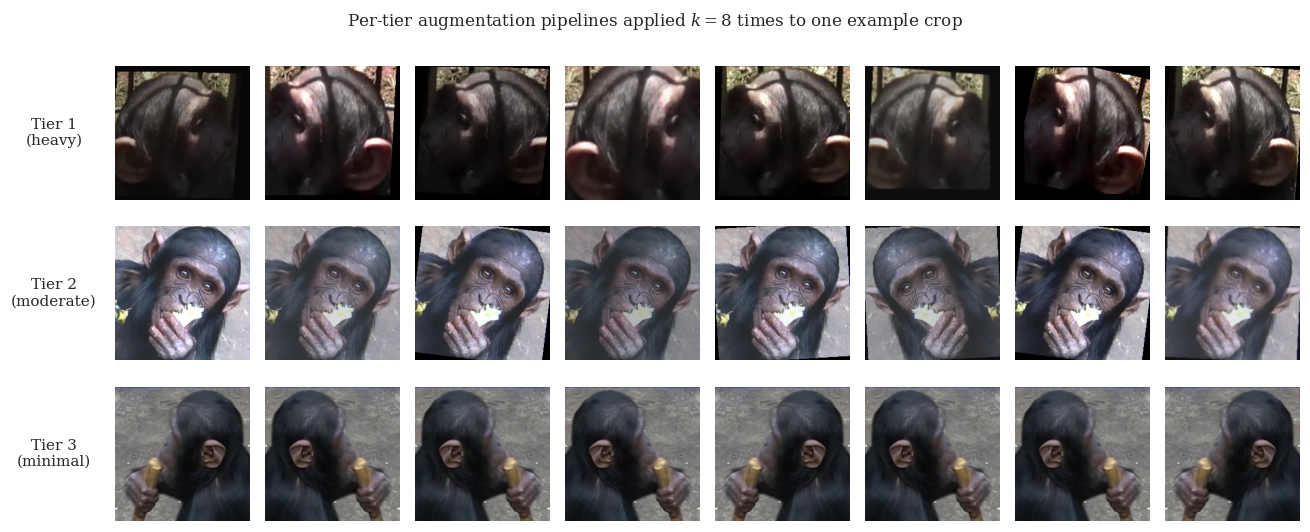

In [111]:
try:
    from torchvision import transforms
except ImportError:
    transforms = None

IMAGE_SIZE = 224
K_AUGS     = 8


def _pick_example(root: Path) -> Path | None:
    for d in list_class_dirs(root):
        for p in sorted(d.iterdir()):
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                return p
    return None


examples = {
    1: _pick_example(TRAIN_ROOT),
    2: _pick_example(STUDENT_ROOT),
    3: _pick_example(TIER3_ROOT),
}
print({t: str(p) if p else None for t, p in examples.items()})

if transforms is None or any(p is None for p in examples.values()):
    print("Skipping augmentation grid (torchvision missing or no example crops found).")
else:
    norm_in  = transforms.Compose([])  # we visualise BEFORE normalisation

    tier1_aug = transforms.Compose([
        transforms.Resize(int(IMAGE_SIZE * 1.15)),
        transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0), ratio=(0.85, 1.15)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([transforms.RandomRotation(degrees=15, fill=0)], p=0.7),
        transforms.RandomApply([transforms.RandomAffine(degrees=0, translate=(0.06, 0.06),
                                                       scale=(0.9, 1.1), shear=5)], p=0.5),
        transforms.RandomPerspective(distortion_scale=0.15, p=0.3),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.25, hue=0.05),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.25),
        transforms.RandomGrayscale(p=0.05),
    ])

    tier2_aug = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomApply([transforms.RandomRotation(degrees=8)], p=0.4),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.03),
        transforms.RandomApply([transforms.GaussianBlur(3)], p=0.15),
    ])

    tier3_aug = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
    ])

    aug_per_tier = {1: tier1_aug, 2: tier2_aug, 3: tier3_aug}
    label_per_tier = {
        1: "Tier 1\n(heavy)",
        2: "Tier 2\n(moderate)",
        3: "Tier 3\n(minimal)",
    }

    fig, axes = plt.subplots(3, K_AUGS, figsize=(K_AUGS * 1.5, 5.0))
    rng = random.Random(0)
    for row, tier in enumerate([1, 2, 3]):
        img = Image.open(examples[tier]).convert("RGB")
        axes[row, 0].set_ylabel(label_per_tier[tier], rotation=0, labelpad=40,
                                fontsize=10, va="center")
        for col in range(K_AUGS):
            out = aug_per_tier[tier](img)
            axes[row, col].imshow(out)
            axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
            for spine in axes[row, col].spines.values():
                spine.set_visible(False)

    fig.suptitle("Per-tier augmentation pipelines applied $k = 8$ times to one example crop",
                 fontsize=11)
    fig.tight_layout()
    save_fig("per_tier_augmentation_grid")
    plt.show()


## 15.&nbsp; Summary tables for thesis inclusion

The cell below exports the three canonical summary tables of this section
into `tables/data_pipeline/` as CSV files and prints a LaTeX preview of
each one. They are the ground truth referenced by the thesis section
§`sec:chimpufe_finetune` and should be cited there using `\input{...}`
or pasted into a `tabular` environment.

| File | Description |
|------|-------------|
| `tier_summary.csv`         | Per-tier headline counts, loss weights, sample multipliers. |
| `per_class_counts.csv`     | One row per chimp, columns for every (tier, split). |
| `rejection_reasons.csv`    | Frequency of every rejection reason in the mining cascade. |

Together with the figures saved into `figures/data_pipeline/`, they form
the canonical artefacts of the data section of the thesis.


In [112]:
tier_summary_path  = TAB_DIR / "tier_summary.csv"
per_class_path     = TAB_DIR / "per_class_counts.csv"
rejection_path     = TAB_DIR / "rejection_reasons.csv"

per_tier_summary.to_csv(tier_summary_path, index=False)
combined.to_csv(per_class_path, index=False)
if not rejection_table.empty:
    rejection_table.to_csv(rejection_path, index=False)

print(f"Saved : {tier_summary_path}")
print(f"Saved : {per_class_path}")
if not rejection_table.empty:
    print(f"Saved : {rejection_path}")

print("\n--- per_tier_summary (LaTeX) ---\n")
print(per_tier_summary.to_latex(index=False, float_format="%.2f", na_rep="--"))

print("\n--- per_class_counts (LaTeX) ---\n")
print(combined.to_latex(index=False, float_format="%.0f"))

if not rejection_table.empty:
    print("\n--- rejection_reasons (LaTeX) ---\n")
    print(rejection_table[rejection_table["count"] > 0]
          .to_latex(index=False, float_format="%.2f"))


Saved : /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/data_engine/results/tables/tier_summary.csv
Saved : /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/data_engine/results/tables/per_class_counts.csv
Saved : /home/users/t/r/trixen/ChimpRec/Code/Recognition/FaceEmbedder_finetuning/data_engine/results/tables/rejection_reasons.csv

--- per_tier_summary (LaTeX) ---

\begin{tabular}{llrrr}
\toprule
tier & split & n_images & loss_weight & sample_mult \\
\midrule
Tier 1 (curated) & train & 866 & 1.00 & 5.00 \\
Tier 1 (curated) & val & 227 & -- & -- \\
Tier 2 (student) & train & 442 & 1.50 & 3.00 \\
Tier 2 (student) & val & 80 & -- & -- \\
Tier 3 (video, frontal>=0.55) & train & 18225 & 0.04 & 1.00 \\
\bottomrule
\end{tabular}


--- per_class_counts (LaTeX) ---

\begin{tabular}{lrrrrrrr}
\toprule
chimp & tier1_train & tier1_val & tier2_train & tier2_val & tier3_train & train_total & val_total \\
\midrule
binasera & 44 & 11 & 46 & 8 & 3691 &

### Closing remarks

This notebook has documented the complete data construction pipeline that
underlies the ChimpUFE fine-tuning. We have shown that:

1. The supervised corpus is naturally heterogeneous &mdash; from a small
   curated gallery to thousands of weakly-labelled video crops &mdash; and
   the only way to exploit all of it without contaminating the optimiser
   is to organise the data into **explicit quality tiers**.
2. The video reservoir is built **for free** from the same named tracking
   files that are used for HOTA evaluation in §`sec:hota_data`, by
   running YOLOX face detection inside each named body box and gating
   the result through a chimp-specific quality cascade.
3. The per-class imbalance that the cascade leaves behind is corrected
   simultaneously by **per-class inverse-frequency sampling** and by
   **per-tier loss/sample weighting**, so that a small number of
   curated images still dominates the gradient over a much larger
   number of mined crops.
4. The held-out test set is **physically separated** from every
   training pool, and a programmatic leakage check guarantees this on
   every run.

The figures saved into `figures/data_pipeline/` and the tables saved into
`tables/data_pipeline/` are the canonical artefacts referenced by the
thesis Data chapter.


## 16.&nbsp; Reproducibility &mdash; exact production commands

The two shell commands below are the **exact** invocations used to
produce the production Tier&nbsp;3 pool and the fine-tuned ChimpUFE
checkpoint discussed in this notebook. They are pinned here so that the
thesis can cite a single, stable reference.

**Step A &mdash; mine Tier&nbsp;3 (`face_crops_frontal_55/`).**
The raw reservoir `face_crops_for_chimpufe/` (produced by
`extract_face_crops_from_named_tracks.py`) is filtered down with
`filter_frontal_faces.py` using the production thresholds
$(\text{frontal\_score} \geq 0.55,\; \text{eye\_count} \geq 1)$.

**Step B &mdash; fine-tune ChimpUFE.**
The Slurm script
`Code/Recognition/ChimpUFE/run_ceci/run_finetune_t3_frontal55.slurm`
launches `chimpUFE_finetune_intensive.py` with the per-tier loss/sample
weights documented above, the per-image draw cap
$\textsf{max\_resample}=3$, ArcFace + EMA, and writes its outputs into
`runs/chimpufe_ft_t3_frontal55V2/`.


In [113]:
# ---------------------------------------------------------------------------
# Production commands (pinned for reproducibility / thesis appendix).
#
# These are the exact shell invocations that produced the Tier-3 pool and
# the fine-tuned ChimpUFE checkpoint described in this notebook. The values
# below mirror the live Slurm script
#   Code/Recognition/ChimpUFE/run_ceci/run_finetune_t3_frontal55.slurm
# and the filter call documented in section 7.
# ---------------------------------------------------------------------------

PROD_FILTER_CMD = r"""
python Code/Recognition/ChimpUFE/filter_frontal_faces.py \
    --input-root        ChimpPic/face_recognition_db/face_crops_for_chimpufe \
    --output-root       ChimpPic/face_recognition_db/face_crops_frontal_55 \
    --min-frontal-score 0.55 \
    --min-eye-count     1 \
    --show-progress
""".strip()

PROD_FINETUNE_CMD = r"""
PYTHONUNBUFFERED=1 python -u Code/Recognition/ChimpUFE/chimpUFE_finetune_intensive.py \
    --db-root             ChimpPic/face_recognition_db \
    --train-root          ChimpPic/face_recognition_db/chimpRecV1_faces/train \
    --val-root            ChimpPic/face_recognition_db/chimpRecV1_faces/val \
    --student-root        ChimpPic/face_recognition_db/student_face_crops \
    --tier3-root          ChimpPic/face_recognition_db/face_crops_frontal_55 \
    --tier1-loss-weight   1.0 \
    --tier2-loss-weight   1.5 \
    --tier3-loss-weight   0.045 \
    --tier1-sample-mult   5.0 \
    --tier2-sample-mult   3.0 \
    --tier3-sample-mult   1.0 \
    --tier3-max-per-class 0 \
    --max-resample        3.0 \
    --no-tier3-augmentation \
    --epochs-stage1       6 \
    --epochs-stage2       100 \
    --batch-size          64 \
    --num-workers         12 \
    --use-arcface \
    --use-ema \
    --early-stopping-patience 20 \
    --log-every           5 \
    --out-dir             Code/Recognition/ChimpUFE/runs/chimpufe_ft_t3_frontal55V2
""".strip()

# Slurm header used for the run on the CECI cluster.
PROD_SLURM_HEADER = r"""
#!/bin/bash
#SBATCH --job-name=chimpufe_ft_t3_f55
#SBATCH --partition=batch
#SBATCH --gres=gpu:1
#SBATCH --time=24:00:00
#SBATCH --ntasks=12
#SBATCH --mem=64G
#SBATCH --output=logs/chimpufe_ft_t3_f55_%j.out
#SBATCH --error=logs/chimpufe_ft_t3_f55_%j.err
""".strip()

print("=" * 78)
print("STEP A  -  Tier-3 mining filter")
print("=" * 78)
print(PROD_FILTER_CMD)
print()
print("=" * 78)
print("STEP B  -  ChimpUFE fine-tuning (Slurm header)")
print("=" * 78)
print(PROD_SLURM_HEADER)
print()
print("=" * 78)
print("STEP B  -  ChimpUFE fine-tuning (training command)")
print("=" * 78)
print(PROD_FINETUNE_CMD)


STEP A  -  Tier-3 mining filter
python Code/Recognition/ChimpUFE/filter_frontal_faces.py \
    --input-root        ChimpPic/face_recognition_db/face_crops_for_chimpufe \
    --output-root       ChimpPic/face_recognition_db/face_crops_frontal_55 \
    --min-frontal-score 0.55 \
    --min-eye-count     1 \
    --show-progress

STEP B  -  ChimpUFE fine-tuning (Slurm header)
#!/bin/bash
#SBATCH --job-name=chimpufe_ft_t3_f55
#SBATCH --partition=batch
#SBATCH --gres=gpu:1
#SBATCH --time=24:00:00
#SBATCH --ntasks=12
#SBATCH --mem=64G
#SBATCH --output=logs/chimpufe_ft_t3_f55_%j.out
#SBATCH --error=logs/chimpufe_ft_t3_f55_%j.err

STEP B  -  ChimpUFE fine-tuning (training command)
PYTHONUNBUFFERED=1 python -u Code/Recognition/ChimpUFE/chimpUFE_finetune_intensive.py \
    --db-root             ChimpPic/face_recognition_db \
    --train-root          ChimpPic/face_recognition_db/chimpRecV1_faces/train \
    --val-root            ChimpPic/face_recognition_db/chimpRecV1_faces/val \
    --student-roo